# 🎬 05 — Neural Collaborative Filtering (NCF)
Trains a custom PyTorch Deep Learning recommendation model. Includes embedding layers for users and items, fed into multi-layer perceptron (MLP) layers, and trains the network in regression mode.

Starting NCF training...


Training NCF on device: cpu


Epoch 1/5 | Loss: 1.0145 | RMSE: 1.0072


Epoch 2/5 | Loss: 0.8409 | RMSE: 0.9170


Epoch 3/5 | Loss: 0.7704 | RMSE: 0.8777


Epoch 4/5 | Loss: 0.7156 | RMSE: 0.8459


Epoch 5/5 | Loss: 0.6741 | RMSE: 0.8210


NCF model weights saved to ../models/ncf_model.pt
NCF mappings saved to ../models/ncf_mappings.pkl


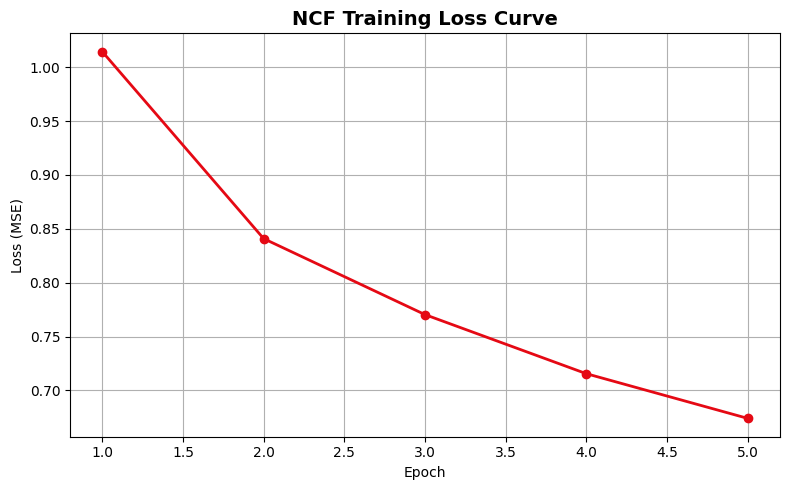

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.models.ncf_model import train_ncf, save_ncf_model

train_df = pd.read_parquet('../data/processed/train.parquet')

# Sample for neural model to run fast (~1-2 minutes)
ncf_sample = train_df.sample(min(1000000, len(train_df)), random_state=42)

print("Starting NCF training...")
model, user2idx, movie2idx, losses = train_ncf(
    ncf_sample,
    n_epochs=5,
    batch_size=2048,
    lr=0.001,
    n_factors=32,
    layers=[64, 32]
)

# Save weights and index mappings
save_ncf_model(model, user2idx, movie2idx, '../models/ncf_model.pt', '../models/ncf_mappings.pkl')

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses)+1), losses, marker='o', color='#E50914', linewidth=2)
plt.title('NCF Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/figures/ncf_loss.png', dpi=150, bbox_inches='tight')
plt.show()